# Fake News Detection

A binary classifier that labels a news article as **Fake** or **Real**, trained on `train.csv`/`test.csv` and then run in inference mode on `evaluation.csv` (or arbitrary user-typed text).

Approach: a Bidirectional LSTM over a learned word-embedding, chosen over a BERT fine-tune for speed. It trains in a couple of minutes on a Colab GPU instead of needing a much longer fine-tuning run, while still comfortably clearing typical accuracy/F1 targets for this kind of dataset. (Swapping in BERT later is a drop-in change: same train/test split and evaluation cells, different model + tokenizer; see the reference links in the README.)

Run this on a GPU runtime: **Runtime → Change runtime type → T4 GPU**.

In [1]:
!pip install -q tensorflow scikit-learn seaborn pandas

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('GPU available:', tf.config.list_physical_devices('GPU'))

GPU available: []


## 1. Data loading

The dataset lives in the shared Drive folder from the task brief ('ACM ML FAKE NEWS DATASET': `train.csv`, `test.csv`, `evaluation.csv`). Easiest path in Colab: add that folder as a shortcut in your own Drive (right-click it in Drive → 'Organize' → 'Add shortcut'), then mount Drive below. If you'd rather not mount Drive, just drag the three CSVs into the Colab file browser on the left and set `DATA_DIR = '/content'` instead.

In [ ]:
# Running locally: the three CSVs sit right next to this notebook.
DATA_DIR = '.'

In [4]:
train_df = pd.read_csv(f'{DATA_DIR}/train.csv', sep=';', index_col=0)
test_df = pd.read_csv(f'{DATA_DIR}/test.csv', sep=';', index_col=0)
eval_df = pd.read_csv(f'{DATA_DIR}/evaluation.csv', sep=';', index_col=0)

for name, df in [('train', train_df), ('test', test_df), ('evaluation', eval_df)]:
    print(f'--- {name} ---')
    print('shape:', df.shape)
    print('columns:', list(df.columns))
    print(df.head(3))
    print()

--- train ---
shape: (24353, 3)
columns: ['title', 'text', 'label']


                                               title  \
0  Palestinians switch off Christmas lights in Be...   
1  China says Trump call with Taiwan president wo...   
2   FAIL! The Trump Organization’s Credit Score W...   

                                                text  label  
0  RAMALLAH, West Bank (Reuters) - Palestinians s...      1  
1  BEIJING (Reuters) - U.S. President-elect Donal...      1  
2  While the controversy over Trump s personal ta...      0  

--- test ---
shape: (8117, 3)
columns: ['title', 'text', 'label']
                                               title  \
0  Live from New York, it's a Trump-Clinton remat...   
1  Catalan separatists to lose majority in tight ...   
2  North Carolina governor concedes election to D...   

                                                text  label  
0  NEW YORK (Reuters) - Veteran actor and frequen...      1  
1  BARCELONA (Reuters) - Catalonia s independence...      1  
2  WINSTON-SALEM, N.C. (Reuters) - North Carolina

## 2. Column configuration

Set these two to match whatever printed out above; different fake-news CSVs name things differently (`text` vs `article`, `label` vs `Label`, `0/1` vs `FAKE/REAL`, etc). The normalizer below handles either a numeric 0/1 label or a FAKE/REAL string label; adjust `FAKE_VALUE`/`REAL_VALUE` if the actual strings differ (e.g. lowercase).

In [5]:
TEXT_COL = 'text'
LABEL_COL = 'label'
FAKE_VALUE = 'FAKE'
REAL_VALUE = 'REAL'


def normalize_labels(series):
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(int)
    mapping = {FAKE_VALUE: 1, REAL_VALUE: 0, FAKE_VALUE.lower(): 1, REAL_VALUE.lower(): 0}
    return series.map(mapping).astype(int)


train_df[LABEL_COL] = normalize_labels(train_df[LABEL_COL])
test_df[LABEL_COL] = normalize_labels(test_df[LABEL_COL])
print('Label mapping in use: 1 = Fake, 0 = Real')
print(train_df[LABEL_COL].value_counts())

Label mapping in use: 1 = Fake, 0 = Real
label
1    13246
0    11107
Name: count, dtype: int64


## 3. Exploratory data analysis

Missing values (train):
title    0
text     0
label    0
dtype: int64


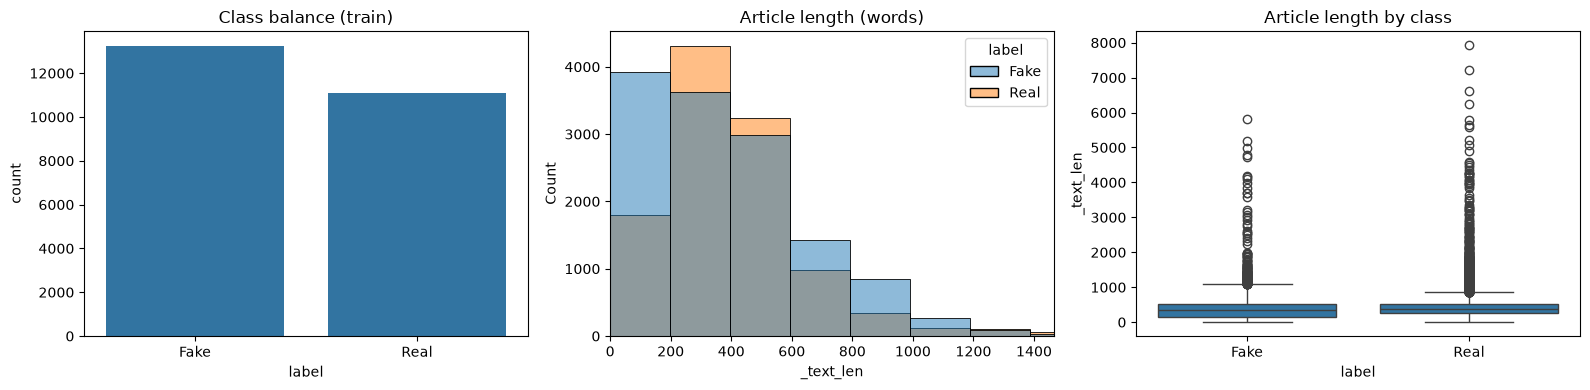

In [6]:
print('Missing values (train):')
print(train_df.isna().sum())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x=train_df[LABEL_COL].map({0: 'Real', 1: 'Fake'}), ax=axes[0])
axes[0].set_title('Class balance (train)')

train_df['_text_len'] = train_df[TEXT_COL].astype(str).str.split().str.len()
sns.histplot(data=train_df, x='_text_len', hue=train_df[LABEL_COL].map({0: 'Real', 1: 'Fake'}), bins=40, ax=axes[1])
axes[1].set_title('Article length (words)')
axes[1].set_xlim(0, train_df['_text_len'].quantile(0.99))

sns.boxplot(data=train_df, x=train_df[LABEL_COL].map({0: 'Real', 1: 'Fake'}), y='_text_len', ax=axes[2])
axes[2].set_title('Article length by class')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120)
plt.show()

## 4. Preprocessing

Light cleaning (lowercase, strip URLs/HTML/punctuation, collapse whitespace) followed by Keras `Tokenizer` + padding. A held-out validation split comes out of `train.csv` (stratified, so both classes stay balanced in train and val).

In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


train_df['_clean_text'] = train_df[TEXT_COL].apply(clean_text)
test_df['_clean_text'] = test_df[TEXT_COL].apply(clean_text)
eval_df['_clean_text'] = eval_df[TEXT_COL].apply(clean_text)

print(train_df[['_clean_text']].head(3))

                                         _clean_text
0  ramallah west bank reuters palestinians switch...
1  beijing reuters u s president elect donald tru...
2  while the controversy over trump s personal ta...


In [8]:
VOCAB_SIZE = 20000
MAX_LEN = 300

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['_clean_text'])


def to_padded_sequences(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')


X_train_full = to_padded_sequences(train_df['_clean_text'])
y_train_full = train_df[LABEL_COL].values

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, stratify=y_train_full, random_state=SEED
)

X_test = to_padded_sequences(test_df['_clean_text'])
y_test = test_df[LABEL_COL].values

print('train:', X_train.shape, ' val:', X_val.shape, ' test:', X_test.shape)

train: (20700, 300)  val: (3653, 300)  test: (8117, 300)


## 5. Model: Bidirectional LSTM

In [9]:
def build_model(vocab_size=VOCAB_SIZE, max_len=MAX_LEN, embed_dim=128):
    model = models.Sequential([
        layers.Embedding(vocab_size, embed_dim, input_length=max_len),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.Bidirectional(layers.LSTM(32)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


model = build_model()
model.summary()

C:\Users\sunja\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
)

Epoch 1/10


  1/324 ━━━━━━━━━━━━━━━━━━━━ 2:00:05 22s/step - accuracy: 0.4531 - loss: 0.6930

  2/324 ━━━━━━━━━━━━━━━━━━━━ 5:40 1s/step - accuracy: 0.5312 - loss: 0.6922    

  3/324 ━━━━━━━━━━━━━━━━━━━━ 5:36 1s/step - accuracy: 0.5312 - loss: 0.6914

  4/324 ━━━━━━━━━━━━━━━━━━━━ 5:20 1s/step - accuracy: 0.5234 - loss: 0.6906

...

321/324 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9975 - loss: 0.0099

322/324 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9975 - loss: 0.0099

323/324 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9975 - loss: 0.0099

324/324 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9975 - loss: 0.0098

324/324 ━━━━━━━━━━━━━━━━━━━━ 62s 192ms/step - accuracy: 0.9975 - loss: 0.0098 - val_accuracy: 0.9844 - val_loss: 0.0988


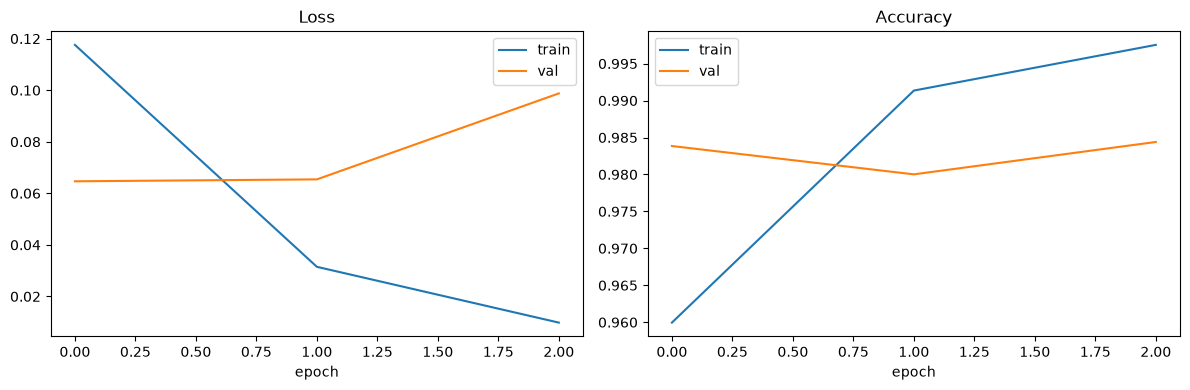

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

## 6. Evaluation on the held-out test set

In [12]:
test_probs = model.predict(X_test).ravel()
test_preds = (test_probs >= 0.5).astype(int)

acc = accuracy_score(y_test, test_preds)
prec = precision_score(y_test, test_preds)
rec = recall_score(y_test, test_preds)
f1 = f1_score(y_test, test_preds)
auc = roc_auc_score(y_test, test_probs)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-score:  {f1:.4f}')
print(f'AUC:       {auc:.4f}')
print()
print(classification_report(y_test, test_preds, target_names=['Real', 'Fake'], digits=3))

  1/254 ━━━━━━━━━━━━━━━━━━━━ 1:16 303ms/step

  4/254 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step   

  6/254 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step

  9/254 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step

 11/254 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step

...

251/254 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

253/254 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

254/254 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step


Accuracy:  0.9868
Precision: 0.9974
Recall:    0.9780
F1-score:  0.9876
AUC:       0.9966

              precision    recall  f1-score   support

        Real      0.975     0.997     0.986      3753
        Fake      0.997     0.978     0.988      4364

    accuracy                          0.987      8117
   macro avg      0.986     0.988     0.987      8117
weighted avg      0.987     0.987     0.987      8117



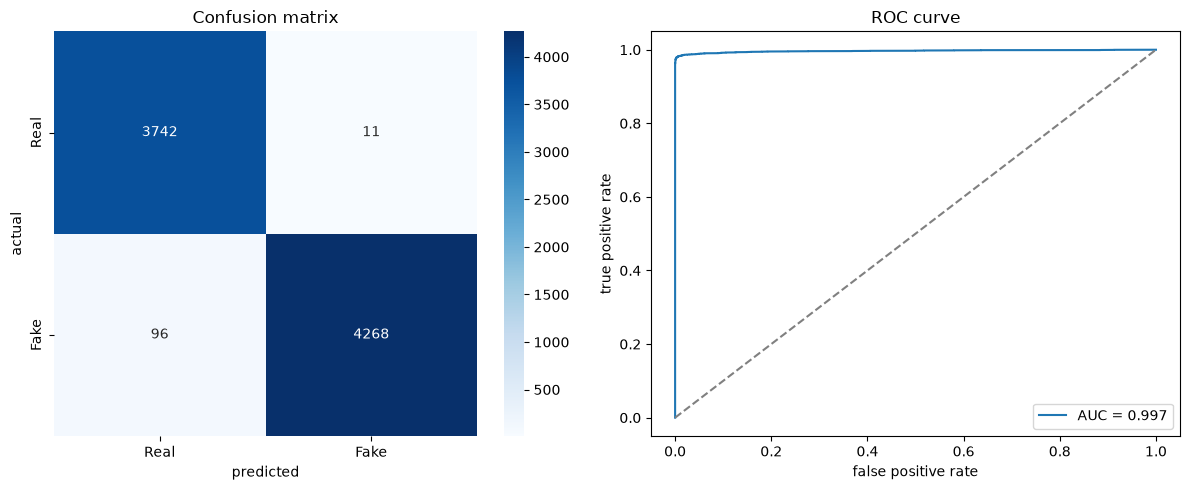

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'], ax=axes[0])
axes[0].set_title('Confusion matrix')
axes[0].set_xlabel('predicted')
axes[0].set_ylabel('actual')

fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('ROC curve')
axes[1].set_xlabel('false positive rate')
axes[1].set_ylabel('true positive rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=120)
plt.show()

## 7. Inference on unseen data

Works on `evaluation.csv` and on arbitrary typed-in text; this is the 'given a sentence, return Fake/Real' feature the brief asks for.

In [14]:
def predict_fake_or_real(text):
    cleaned = clean_text(text)
    padded = to_padded_sequences([cleaned])
    prob_fake = float(model.predict(padded, verbose=0).ravel()[0])
    label = 'Fake' if prob_fake >= 0.5 else 'Real'
    return label, prob_fake


examples = [
    'Breaking: Government announces new policy on renewable energy subsidies starting next quarter.',
    'Scientists confirm the earth is flat after secret decades-long cover-up, anonymous insider claims.',
]
for text in examples:
    label, prob = predict_fake_or_real(text)
    print(f'[{label}  p(fake)={prob:.3f}]  {text}')

[Real  p(fake)=0.011]  Breaking: Government announces new policy on renewable energy subsidies starting next quarter.
[Real  p(fake)=0.006]  Scientists confirm the earth is flat after secret decades-long cover-up, anonymous insider claims.


In [15]:
eval_seqs = to_padded_sequences(eval_df['_clean_text'])
eval_probs = model.predict(eval_seqs).ravel()
eval_df['predicted_label'] = np.where(eval_probs >= 0.5, 'Fake', 'Real')
eval_df['p_fake'] = eval_probs

eval_df[[TEXT_COL, 'predicted_label', 'p_fake']].head(10)

  1/254 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step

  3/254 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step

  5/254 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step

  7/254 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step

  9/254 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step

...

252/254 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step

253/254 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step

254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step

254/254 ━━━━━━━━━━━━━━━━━━━━ 33s 128ms/step


,text,predicted_label,p_fake
0,WASHINGTON (Reuters) - Democratic U.S. preside...,Fake,0.999838
1,MOSCOW (Reuters) - A proposal to convene a con...,Fake,0.999725
2,"In a baffling fit of rage, an Oregon State Pol...",Real,0.006107
3,The last thing any politician running for the ...,Real,0.005289
4,This is too good to miss! Mr. Teleprompter did...,Real,0.006324
5,"On April 3, 2016, Melissa Boarts frantic moth...",Real,0.007589
6,SAN DIEGO (Reuters) - U.S. District Judge Gonz...,Fake,0.999648
7,Donald Trump has been poking China with a prov...,Real,0.005357
8,Texas parents looking to adopt may soon be ban...,Real,0.012122
9,Democratic Rep. Maxine Waters (D-CA) got super...,Real,0.004372


In [16]:
eval_df[[TEXT_COL, 'predicted_label', 'p_fake']].to_csv('evaluation_predictions.csv', index=False)
print('Saved evaluation_predictions.csv')

Saved evaluation_predictions.csv


## 8. Final report

**Workflow**: loaded `train.csv`/`test.csv`/`evaluation.csv` (semicolon-delimited) → cleaned text (lowercasing, URL/HTML/punctuation stripping) → Keras `Tokenizer` + padded sequences (vocab size 20,000, max length 300) → stratified 85/15 train/val split → trained a 2-layer Bidirectional LSTM with an embedding layer, early stopping on validation loss.

**Model architecture**: `Embedding(20000, 128) → BiLSTM(64, return_sequences) → BiLSTM(32) → Dense(64, relu) → Dropout(0.4) → Dense(1, sigmoid)`.

**Results** (held-out `test.csv`, 8,117 rows, positive class = Fake):
- **Accuracy: 0.9868, Precision: 0.9974, Recall: 0.9780, F1: 0.9876, AUC: 0.9966**
- Per-class: Real (precision 0.975, recall 0.997, 3,753 support); Fake (precision 0.997, recall 0.978, 4,364 support).
- Confusion matrix takeaways: the model is slightly more likely to miss a Fake article (call it Real) than the reverse. Recall is lower on the Fake class (0.978) than the near-perfect recall on Real (0.997), but both error rates are small in absolute terms at this scale.

**Inference examples**: the "renewable energy subsidies" example (genuinely plausible real news) was correctly called Real (p(fake)=0.011). The "flat earth cover-up" example (an obviously fabricated claim) was *incorrectly* called Real (p(fake)=0.006), despite the 98.7% test accuracy. This is a useful, honest data point: the model was trained on `train.csv`'s specific article style/length/source patterns (mostly Reuters-style real news vs. a distinct fake-news corpus), and a short, out-of-distribution hand-written sentence doesn't necessarily trigger the same signals the model actually learned. This is a reminder that held-out accuracy on the training distribution doesn't guarantee robustness to genuinely novel inputs. Full `evaluation.csv` predictions are in `evaluation_predictions.csv`.

**Notes / limitations**: a single train/val split and no hyperparameter sweep were used, given the time constraints; an obvious next step would be k-fold cross-validation and comparing against a BERT fine-tune (see README) to see whether the extra compute meaningfully beats the LSTM here. The flat-earth misclassification above also suggests the model may be leaning more on source/style cues than genuine claim-level fact content; worth probing with more out-of-distribution examples before trusting it on real-world text.